Pneumonia Detection using Custom CNN

In [2]:
#Step-1:- Import Necessary Library
import os

NORMAL : 1341
PNEUMONIA : 3875
[[ 42  43  45 ...   0   0   0]
 [ 37  40  41 ...   0   0   0]
 [ 44  40  32 ...   0   0   0]
 ...
 [255 251 255 ... 251 255 255]
 [  0   0   0 ...   8   0   0]
 [255   2  36 ...  41  36  34]] [[ 77  78  77 ... 190 194 196]
 [ 75  75  76 ... 191 196 199]
 [ 73  71  70 ... 192 197 201]
 ...
 [ 13  13  13 ... 197 196 196]
 [ 13  13  13 ... 197 197 197]
 [ 13  13  13 ... 198 198 198]]


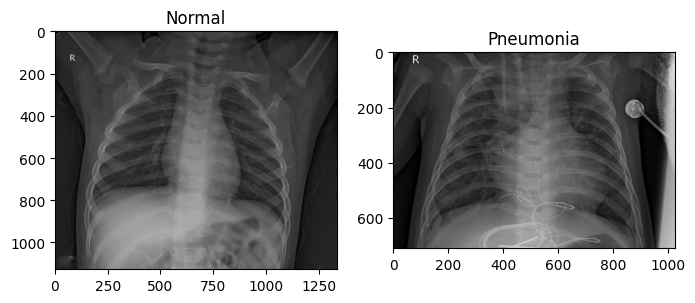

In [3]:

#Step-2:- Load AND Explore the data
#loading the data
train_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
val_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'
test_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'
paths=[]
#print(len(os.listdir("/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL")))
for category in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(train_dir, category)
    paths.append(path)
    print(category, ":", len(os.listdir(path)))

#exploring the data
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

normal_img=mpimg.imread(os.path.join(paths[0],os.listdir(paths[0])[0]))
pneumonia_img=mpimg.imread(os.path.join(paths[1],os.listdir(paths[1])[0]))
print(normal_img,pneumonia_img)

fig,ax=plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(normal_img,cmap="gray")
ax[0].set_title("Normal")
ax[1].imshow(pneumonia_img,cmap="gray")
ax[1].set_title("Pneumonia")
plt.show()



In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#Step-3(Preprocessing the data)
#training data generator with augmentation
train_gen=ImageDataGenerator(
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

#validating data generator,with no augmentation, only rescaling
val_gen=ImageDataGenerator(
    rescale=1./255,
)

#testing data generator, with no augmentation, only rescaling
test_gen=ImageDataGenerator(
    rescale=1./255,
)

#Flows Images from directory
train_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

val_data=val_gen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

test_data=test_gen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

2025-12-29 13:35:07.776614: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767015308.099293      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767015308.185364      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [5]:
from tensorflow.keras import models,layers
#Step-4:- Defining Model Architecture(input and output features)
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1,activation="sigmoid"),
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-29 13:35:34.281279: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
#Step-5:- Compile the model
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [7]:
#Step-6:- Training the model
history=model.fit(train_data,epochs=10,validation_data=val_data)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.7511 - loss: 0.5793 - val_accuracy: 0.8750 - val_loss: 0.4371
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 158s 966ms/step - accuracy: 0.8923 - loss: 0.2718 - val_accuracy: 0.7500 - val_loss: 0.5156
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 158s 965ms/step - accuracy: 0.9060 - loss: 0.2391 - val_accuracy: 0.7500 - val_loss: 0.4531
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 156s 955ms/step - accuracy: 0.9059 - loss: 0.2252 - val_accuracy: 0.8125 - val_loss: 0.3965
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 156s 952ms/step - accuracy: 0.9272 - loss: 0.1826 - val_accuracy: 0.7500 - val_loss: 0.3742
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 201s 949ms/step - accuracy: 0.9237 - loss: 0.2026 - val_accuracy: 0.6875 - val_loss: 0.7361
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 155s 950ms/step - accuracy: 0.9308 - loss: 0.1838 - val_accuracy: 0.6250 - val_loss: 0.9775
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 155s 949ms/step - accuracy: 0.9361 - lo

In [8]:
#Step-7:- Evaluating the model on test data
test_loss,test_accuracy=model.evaluate(test_data)
print(test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 556ms/step - accuracy: 0.8901 - loss: 0.3481
0.8846153616905212


In [14]:
#Step-8:- Make predictions on new image 
from tensorflow.keras.preprocessing import image
import numpy as np

img_path="/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person101_bacteria_484.jpeg"
img=image.load_img(img_path,target_size=(150,150))
img_arr=image.img_to_array(img)/255.0
img_arr=np.expand_dims(img_arr,axis=0)

prediction=model.predict(img_arr)
diagnosis="PNEUMONIA" if prediction[0][0]>0.5 else "NORMAL"
print("Diagnosis:- ",diagnosis)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Diagnosis:-  PNEUMONIA


In [ ]:
#Step-1:- Import Necessary Libraries
import numpy as np

#Step-2:- Load and Explore the data 
train_dir=
val_dir=
test_dir=

#explore the data 

#finding total images
categories=["NORMAL","PNEUMONIA"]
#for training image
for category in categories:
    print(category,":",os.path.join(train_dir,category))
#for validation image
for category in categories:
    print(category,":",os.path.join(val_dir,category))
#for testing image
for category in categories:
    print(category,":",os.path.join(test_dir,category))

#displaying one image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

path_1=os.path.join(train_dir,categories[0])
path_1=os.path.join(path_1,os.listdir(path_1)[0])

path_2=os.path.join(train_dir,categories[1])
path_2=os.path.join(path_2,os.listdir(path_2)[0])

img_1=mpimg.imread(path_1)
img_2=mpimg.imread(path_2)

fig,ax=plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(img_1)
ax[0].set_title("Normal")
ax[1].imshow(img_2)
ax[1].set_title("Pneumonia")

#Step-3:- Preprocessing the image 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#training image data generator
train_gen=ImageDataGenerator(
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)
#validating image data Generator
val_gen=ImageDataGenerator(
    rescale=1./255,
)
#testing image data generator
test_gen=ImageDataGenerator(
    rescale=1./255,
)
#training images via training image generator
train_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)
#validating images from validating image generator
val_data=val_gen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)
#testing images from testing image generator
test_data=test_gen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

#Step-4:- Defining model architecture
from tensorflow.keras import models,layers
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1,activation="sigmoid"),
    
])

#Step-5:- Compile the model
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

#Step-6:- Train the model
model.fit(train_data,epochs=10,validation_data=val_data)

#Step-7:- Evaluate the model
test_loss,test_accuracy=model.evaluate(test_data)
print("Accuracy:- ",test_accuracy)

#Step-8:- Prediction on new data
from tensorflow.keras.preprocessing import image
img_path=""
img=image.load_img(img_path,target_size=(150,150))
img_array=image.img_to_array(img)/255.0
img_array=np.expand_dims(img_array,axis=0)

predictions=model.predict(img_array)

diagnosis="Pneumonia" if predictions[0][0]>0.5 else "Normal"
print("Daignosis: ",diagnosis)



Pneumonia Detection using VGG 16

2026-01-08 04:40:16.423961: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767847216.768613      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767847216.872601      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

NORMAL : 1341
PNEUMONIA : 3875
NORMAL : 8
PNEUMONIA : 8
NORMAL : 234
PNEUMONIA : 390
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


2026-01-08 04:40:48.758609: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1490s 9s/step - accuracy: 0.6397 - loss: 0.6505 - val_accuracy: 0.5000 - val_loss: 0.7147
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1483s 9s/step - accuracy: 0.7705 - loss: 0.4752 - val_accuracy: 0.5625 - val_loss: 0.6303
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1483s 9s/step - accuracy: 0.8295 - loss: 0.3794 - val_accuracy: 0.5625 - val_loss: 0.6527
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1498s 9s/step - accuracy: 0.8573 - loss: 0.3305 - val_accuracy: 0.7500 - val_loss: 0.5576
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1487s 9s/step - accuracy: 0.8759 - loss: 0.2952 - val_accuracy: 0.7500 - val_loss: 0.5451
20/20 ━━━━━━━━━━━━━━━━━━━━ 173s 9s/step - accuracy: 0.8203 - loss: 0.3915
Test Accuracy:-  0.8333333134651184
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
Diagnosis:-  NORMAL


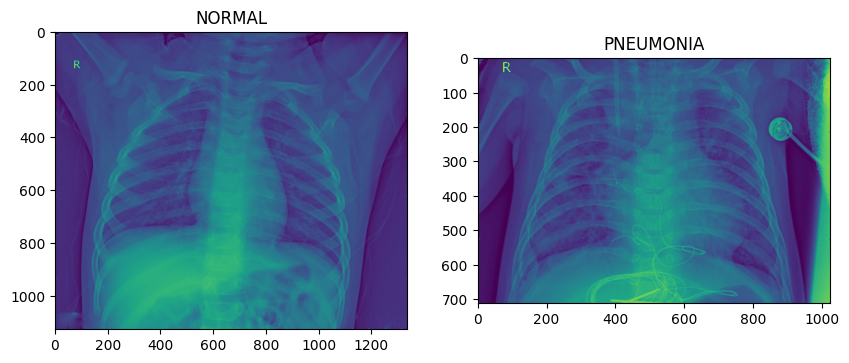

In [1]:
#Step-1: Import Necessary Library
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

#Step-2:- Load and Explore the data 
train_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/test"

#finding the total size of each directory
categories=["NORMAL","PNEUMONIA"]
#for train dir
for category in categories:
    print(category,":",len(os.listdir(os.path.join(train_dir,category))))

#for val dir
for category in categories:
    print(category,":",len(os.listdir(os.path.join(val_dir,category))))

#for test dir
for category in categories:
    print(category,":",len(os.listdir(os.path.join(test_dir,category))))


#viewing sample image 
path_1=os.path.join(train_dir,categories[0])
path_1=os.path.join(path_1,os.listdir(path_1)[0])
path_2=os.path.join(train_dir,categories[1])
path_2=os.path.join(path_2,os.listdir(path_2)[0])

img_1=mpimg.imread(path_1)
img_2=mpimg.imread(path_2)

fig,ax=plt.subplots(1,2,figsize=(10,5))
ax[0].set_title("NORMAL")
ax[0].imshow(img_1)
ax[1].set_title("PNEUMONIA")
ax[1].imshow(img_2)



#Step-3:- Preprocessing the data 
#Training image generator with augmentation
train_gen=ImageDataGenerator(
rescale=1./255,
shear_range=0.1,
zoom_range=0.2,
horizontal_flip=True,
)

#validation image generator no augmentation, only rescaling
val_gen=ImageDataGenerator(
rescale=1./255,
)

#testing image generator with no augmentation, only rescaling 
test_gen=ImageDataGenerator(
rescale=1./255,
)

#processing training image  
train_data=train_gen.flow_from_directory(
train_dir,
target_size=(224,224),
batch_size=32,
class_mode="binary"
)

#processing validation image
val_data=val_gen.flow_from_directory(
val_dir,
target_size=(224,224),
batch_size=32,
class_mode="binary",
)

#processing testing image 
test_data=test_gen.flow_from_directory(
test_dir,
target_size=(224,224),
batch_size=32,
class_mode="binary",
)

#Step-4:- Defining Model architecture(VGG-16)
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models,layers

#Step-4(a)
#vgg_16 acts as a feature extractor and a base of model, not as full predefined VGG model
#because include_top=False, which means that only 13 convolutional layer
#and 5 max-pooling layer was activated, but not the 3 fully connected layers
vgg_base=VGG16(
weights="imagenet",
include_top=False,
input_shape=(224,224,3),
)

#Step-4(b)
#initially freeze all the vgg-16 layers ,so you train your new custom layers first and
#it prevent destroying pretrained knowledge and 
#avoids overfitting and reduces training time 
for layer in vgg_base.layers:
    layer.trainable=False

#Step-4(c)
#Add a custom classifier head and acts as a actual decision maker 
#here you remove original classification layer, and add your own custom classifcation layer
model=models.Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),#replacement of Flatten and more better than Flatten
    layers.Dense(256,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1,activation="sigmoid")
])

#Step-5:- Compile the model
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001),loss="binary_crossentropy",metrics=["accuracy"])

#Step-6:- Train the model
history=model.fit(train_data,epochs=5,validation_data=val_data)

#Step-7:- Evaluate the model
test_loss,test_accuracy=model.evaluate(test_data)
print("Test Accuracy:- ",test_accuracy)

#Step-8:- Prediction on New X-ray images
from tensorflow.keras.preprocessing import image 
path="/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0140-0001.jpeg"
img=image.load_img(path,target_size=(224,224))
img_array=image.img_to_array(img)/255.0
img_array=np.expand_dims(img_array,axis=0)
prediction=model.predict(img_array)
diagnosis="PNEUMONIA" if prediction[0][0]>0.5 else "NORMAL"
print("Diagnosis:- ",diagnosis)

Pneumonia Detection using VGG-19

2026-01-10 05:52:17.710357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768024338.076997      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768024338.191713      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

NORMAL : 1341
PNEUMONIA : 3875
NORMAL : 8
PNEUMONIA : 8
NORMAL : 234
PNEUMONIA : 390
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


2026-01-10 05:52:48.250653: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1641s 10s/step - accuracy: 0.7235 - loss: 0.5816 - val_accuracy: 0.5000 - val_loss: 0.6775
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1633s 10s/step - accuracy: 0.7759 - loss: 0.4496 - val_accuracy: 0.5625 - val_loss: 0.5962
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1646s 10s/step - accuracy: 0.8326 - loss: 0.3769 - val_accuracy: 0.6875 - val_loss: 0.5835
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1656s 10s/step - accuracy: 0.8649 - loss: 0.3298 - val_accuracy: 0.7500 - val_loss: 0.5784
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1642s 10s/step - accuracy: 0.8661 - loss: 0.3088 - val_accuracy: 0.7500 - val_loss: 0.5791
20/20 ━━━━━━━━━━━━━━━━━━━━ 193s 10s/step - accuracy: 0.7548 - loss: 0.4854
Test Accuracy:-  0.754807710647583
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step
Diagnosis:-  Normal


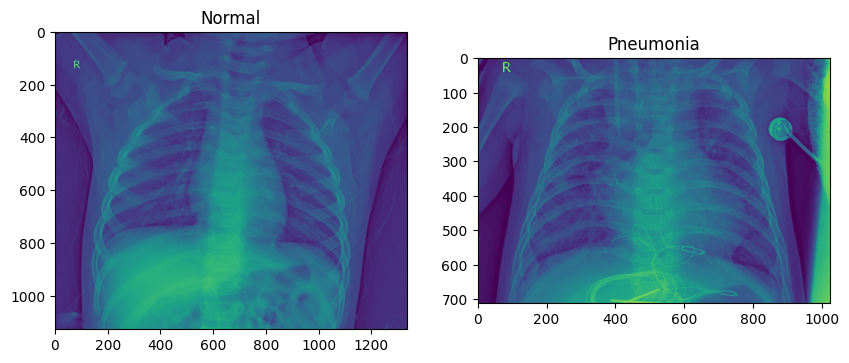

In [1]:

#Step-1:- Import Necessary libraries 
import os 
import numpy as np
import matplotlib.image as mpimg 
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models,layers 
from tensorflow.keras.applications import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

#Step-2:- Load and Explore the data 
#load the data 
train_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/test"

#explore the data 
#calculating total length of directory
categories=["NORMAL","PNEUMONIA"]
for category in categories:
    print(category,":",len(os.listdir(os.path.join(train_dir,category))))

for category in categories:
    print(category,":",len(os.listdir(os.path.join(val_dir,category))))

for category in categories:
    print(category,":",len(os.listdir(os.path.join(test_dir,category))))

#viewing sample image 
path_1=os.path.join(train_dir,categories[0])
path_1=os.path.join(path_1,os.listdir(path_1)[0])
path_2=os.path.join(train_dir,categories[1])
path_2=os.path.join(path_2,os.listdir(path_2)[0])

img_1=mpimg.imread(path_1)
img_2=mpimg.imread(path_2)

fig,ax=plt.subplots(1,2,figsize=(10,5))
ax[0].set_title("Normal")
ax[0].imshow(img_1)
ax[1].set_title("Pneumonia")
ax[1].imshow(img_2)

#Step-3:- Preprocessing the data
#creating training, validating, testing image generator for processing of images
train_gen=ImageDataGenerator(
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
)
val_gen=ImageDataGenerator(
    rescale=1./255,
)
test_gen=ImageDataGenerator(
    rescale=1./255,
)
#processing the images
train_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
)
val_data=val_gen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
)
test_data=test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
)

#Step-4:- Defining model architecture 
#Step-4(a):using VGG-19
from tensorflow.keras.applications import VGG19
vgg19_base=VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3),
)

#Step-4(b): freeze the vgg layers initially
for layer in vgg19_base.layers:
    layer.trainable=False

#Step-4(c): making actual model and add custom classification layers
model=models.Sequential([
    vgg19_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1,activation="sigmoid"),
])

#Step-5:- Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss="binary_crossentropy",metrics=["accuracy"])

#Step-6:- Train the model
model.fit(train_data,epochs=5,validation_data=val_data)

#Step-7:- Evaluate the model
test_loss,test_accuracy=model.evaluate(test_data)
print("Test Accuracy:- ",test_accuracy)

#Step-8:- Prediction on new data 
from tensorflow.keras.preprocessing import image 
path="/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0140-0001.jpeg"
img=image.load_img(path,target_size=(224,224))
img_array=image.img_to_array(img)/255.0
img_array=np.expand_dims(img_array,axis=0)
prediction=model.predict(img_array)
diagnosis="Pneumonia" if prediction[0][0]>0.5 else "Normal"
print("Diagnosis:- ",diagnosis)




Pneumonia Detection using ResNet-18

In [ ]:
#Step-1:- Import Necessary libraries 
import numpy as np
import os

#Step-2:-Load and Explore the data 
train_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir="/kaggle/input/chest-xray-pneumonia/chest_xray/test"

#load the data 
categories=["NORMAL","PNEUMONIA"]
for category in categories:
    print(category,":",len(os.listdir(os.path.join(train_dir,category))))

for category in categories:
    print(category,":",len(os.listdir(os.path.join(val_dir,category))))

for category in categories:
    print(category,":",len(os.listdir(os.path.join(test_dir,category))))

#Step-3:-Preprocessing the image
from torchvision import transforms
from torchvision import datasets

train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),
])

val_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),
])

test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),
])

#Use ImageFolder to read the data and label automatically by ImageFolder
train_data=datasets.ImageFolder(train_dir,transform=train_transform)
val_data=datasets.ImageFolder(val_dir,transform=val_transform)
test_data=datasets.ImageFolder(test_dir,transform=test_transform)

from torch.utils.data import DataLoader
#loads and processes the images batches wise to save memory and make training faster
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
val_loader=DataLoader(val_data,batch_size=32,shuffle=False)
test_loader=DataLoader(test_data,batch_size=32,shuffle=False)

#Step-4:- Device Selection(Cpu/gpu)
import torch
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:- ",device)


#Step-5:- Defining model architecture
from torchvision import models
#Step-5(a) using the pretrained resnet 18 model
model=models.resnet18(pretrained=True)

#Step-5(b) freeze feature extractor, so we do not train whole network by ourself,
#we reuse their learned features
for param in model.parameters():
    param.required_grad=False

#Step-5(c):- making changes to the pretrained model based on our need
#replace last layer, to add our own custom classification layer
import torch.nn as nn
model.fc=nn.Sequential(
    nn.Linear(model.fc.in_features,256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256,1),
    nn.Sigmoid()
)
model=model.to(device)

#Step-6:- Compile the model using Loss function and optimizer
import torch.optim as optim
criterion=nn.BCELoss(),
optimizer=optim.model(model.fc.parameters(),lr=0.001)

#Step-7:-Training the model
epochs=5
for epoch in range(epochs):
    model.train()
    running_loss=0.0
    for images,labels in train_loader:
        images=images.to(device)
        labels=labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_lossh+=loss.item()
    print(f"Epoch [{epoch+1}/{epochs}],Loss: {running_loss/len(train_loader):.4f}")
    
#Step-8:- Evaluate the model
model.eval()
correct=0
total=0
with torch.no_grad():
    for images,labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)
        predicted=(outputs>0.5).int()
        correct+=(predicted.squeeze() == labels).sum().item()
        total+=labels.size(0)
print("Test accuracy:- ",correct/total)

#Step-9:- Prediction on new images
from PIL import image
img=Image.open("").convert("RGB")
img=transform(img)
img=img.unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output=model(img)
print("Diagnosis:- ","Pneumonia" if output.item()>0.5 else "Normal")

        

In [1]:
#Step-1:- Import Necessary Library
import numpy as np
import os

#Step-2:- Load and explore the data 


NORMAL : 1341
PNEUMONIA : 3875
